In [1]:
# Generic packages
import numpy as np 
import matplotlib.pyplot as plt
from os import listdir
import pickle

# Style 
plt.style.use('seaborn-pastel')
#seaborn-pastel

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA, KernelPCA, NMF
from sklearn.model_selection import train_test_split
from sklearn.manifold import Isomap, TSNE, SpectralEmbedding, LocallyLinearEmbedding, MDS
from sklearn.neighbors import NearestNeighbors
from sklearn.mixture import GaussianMixture, BayesianGaussianMixture
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, SpectralClustering, AffinityPropagation, MeanShift
from sklearn.cross_decomposition import CCA, PLSCanonical

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from tqdm.notebook import tqdm

from numpy import trapz
from scipy.signal import savgol_filter
import torch

C:\Users\dalbe\AppData\Local\Temp\ipykernel_15336\908438369.py:8: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-pastel')


In [2]:
def build_dataset(path,size):
    """
    build_dataset(path)

        Import dataset from path, normalize data and separate in train and test datasets.

        -path (str) : Path to the dataset files. 
    """
    X = np.concatenate([np.fromfile(f"{path}{fileName}",dtype=np.float16).reshape(-1,size) for fileName in listdir(path)])
    shape = np.shape(X)

    #X = (X - np.mean(X)) / (np.std(X))
    
    return X

In [3]:
def reduction(X,function,plot=False, **param):
    """
    # reduction(X,function,plot=False,**param)

    Verifies if a function has been saved in the `DR preprocess` folder to avoid unnecessary computation. 

    -X (array-like, sparse matrix) : Inputs of the function that needs to be computed.
    -function (function) : Function that is executed.
    -param (**kwargs) : Multiple keyword arguments to define the parameters of `function`.
    
    """
    # File name
    file_name = f"{str(function.__name__)}_{str(param.items())}"
    print("File name : ", file_name)

    # Check for existing file
    try:
        result = np.load(f"DR preprocess\{file_name}.npy",allow_pickle=True)

    # Compute operation if file does not exist
    except:
        method = function(**param)
        result = method.fit_transform(X)
        np.save(f"DR preprocess\{file_name}",arr=result)
    
    # Plot results
    if plot:
        plt.scatter(result[:, 0], result[:, 1],alpha=0.005)
        plt.xlabel('First principal component')
        plt.ylabel('Second principal component')

    #plt.hist2d(result[:, 0], result[:, 1],bins=300)

    return result

In [4]:
def clustering(X, function, label_return = False,**param):
    """
    # clustering(X,function,**param)

        Run and plot a clustering technique defined with the function parameter.
        The process is based on `sklearn` structure.

    -X (array-like, sparse matrix) : Inputs of the function that needs to be computed.
    -function (function) : Function that is executed.
    -param (**kwargs) : Multiple keyword arguments to define the parameters of `function`.
    """

    labels = function(**param).fit_predict(X)

    plt.scatter(X[:, 0], X[:, 1], c=labels, s=10, cmap='Pastel2', alpha=0.05)
    plt.xlabel('First principal component')
    plt.ylabel('Second principal component')

    if label_return:
        return label_return

In [5]:
def silhouette_kmean(X, max_cluster):

        X = (X - np.min(X)) / (np.max(X) - np.min(X)) 
        X = np.array(X).reshape(-1,1)[::20]
        scores = []

        # Optimal n_cluster search
        for cluster_number in tqdm(range(2,max_cluster+1) , desc="Clusters") :
            clusters = KMeans(n_clusters=cluster_number, random_state=42, algorithm='lloyd', n_init='auto').fit_predict(X)
            scores.append(silhouette_score(X, clusters))

        optimal_cluster = np.argmax(scores) + 2

        # Optimal n_cluster evaluation
        km = KMeans(n_clusters=optimal_cluster, random_state=42, algorithm='lloyd', n_init='auto')
        fit = km.fit(X)
        
        centroids = fit.cluster_centers_
        labels = fit.labels_
        unique_labels = np.unique(labels)

        if len(unique_labels) > 1:
            optimal_score = silhouette_score(X, labels)
        else:
            optimal_score = 0

        clusters = []
        for label in unique_labels:
            clusters.append(X[labels == label])

        centroids_ordered, clusters_ordered = zip(*sorted(zip(centroids, clusters)))

        # Plot clusters
        plt.figure(figsize=(5,3), dpi=200)

        bins = np.linspace(np.min(X), np.max(X), 1000)
        for index1, cluster in enumerate(clusters_ordered):
            plt.hist(cluster , bins, alpha = 0.5, label=f"{index1}")

        plt.xlabel("feature")
        plt.ylabel("counts")
        plt.legend(ncol=3,loc='center left', bbox_to_anchor=(1, 0.5))

        # Print optimal Silhouette score
        print("Number of clusters : ", optimal_cluster)
        print("Silhouette score : ", optimal_score)


        # Plot Silhouette scores
        plt.figure(figsize=(5,3), dpi=200)

        plt.plot(range(2, len(scores)+2), scores, label="Approx Silhouette")

        plt.hlines(optimal_score, 2, len(scores)+2, linestyles='dashed', label="Final Silhouette")
        plt.ylabel("Clustering score")
        plt.xlabel("Number of cluster")
        plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

        #return scores, optimal_cluster, optimal_score, clusters

Text(0.5, 0, 'Time (a.u.)')

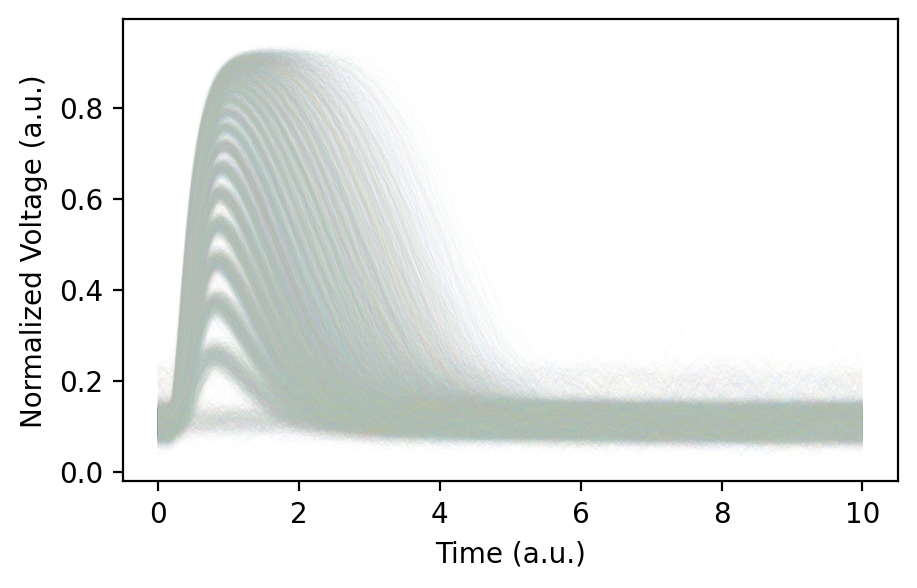

In [6]:
signalSize = 250
X = build_dataset("Datasets/NIST (250)/", signalSize)
time = np.linspace(0, 10, signalSize)

plt.figure(figsize=(5,3), dpi=200)
plot = [plt.plot(time, i,alpha=0.1, linewidth=0.1) for i in X[::10]]

plt.ylabel("Normalized Voltage (a.u.)")
plt.xlabel("Time (a.u.)")
#plt.yticks([])
#plt.xticks([])
#plt.savefig('Trace_NIST.png', transparent=True)


### Filter (Savitzky-Golay)

Some methods are sensitive to noise, a filter is used to smooth the traces and offer more consistent results.

In [7]:
X_filter = savgol_filter(X, 20, 2) # window size 20, polynomial order 2
np.shape(X_filter)

(143360, 250)

([], [])

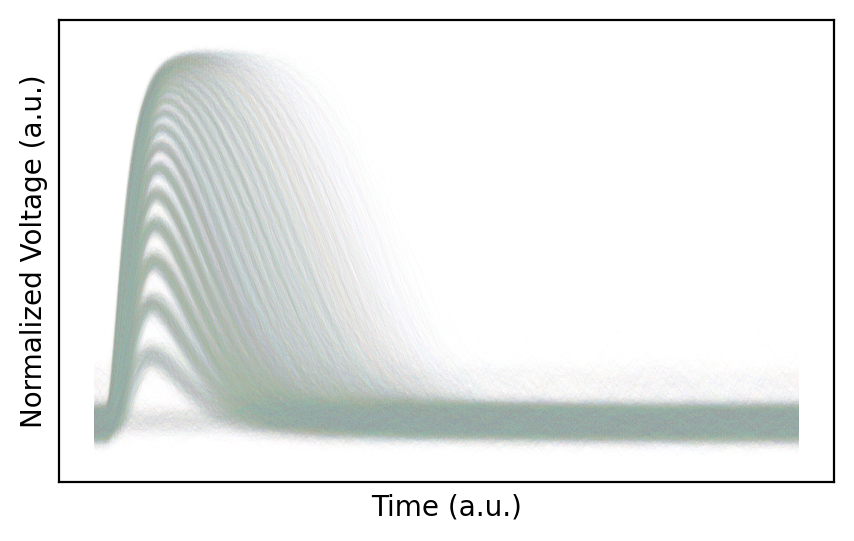

In [8]:
plt.figure(figsize=(5,3), dpi=200)

plot = [plt.plot(time, i, linewidth=0.1, alpha=0.05) for i in X[::10]]

plt.ylabel("Normalized Voltage (a.u.)")
plt.xlabel("Time (a.u.)")
plt.yticks([])
plt.xticks([])
#plt.savefig('Presentation/Trace_NIST.png', transparent=True)

### MAX VALUE

#### Representation

([], [])

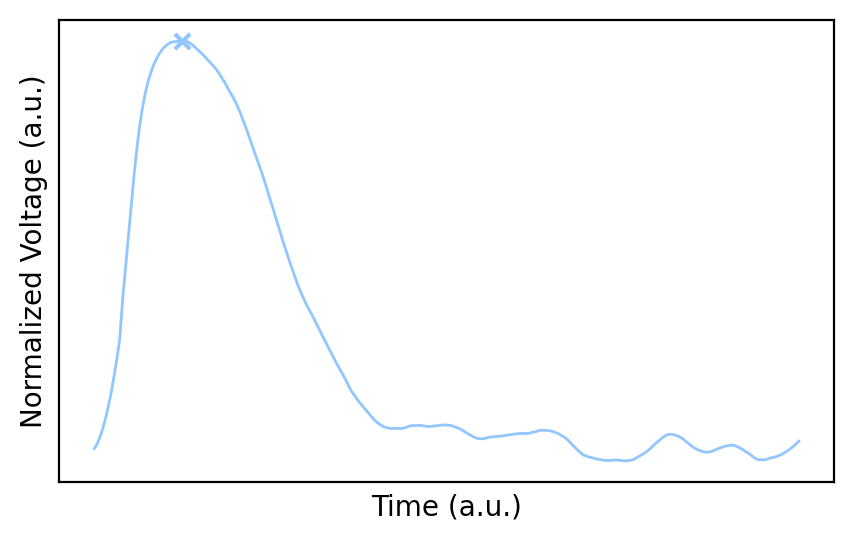

In [9]:
arg_max = np.argmax(X_filter[0])

plt.figure(figsize=(5,3), dpi=200)

plt.scatter(time[arg_max], X_filter[0][arg_max],s=30, marker="x", zorder=10) #,color=[1,1,1]
plt.plot(time, X_filter[0], linewidth=1, alpha=1)

plt.ylabel("Normalized Voltage (a.u.)")
plt.xlabel("Time (a.u.)")
plt.yticks([])
plt.xticks([])
#plt.savefig('Presentation/Trace_MAX.png', transparent=True)

#### Dimensionality reduction

Text(0, 0.5, 'Counts')

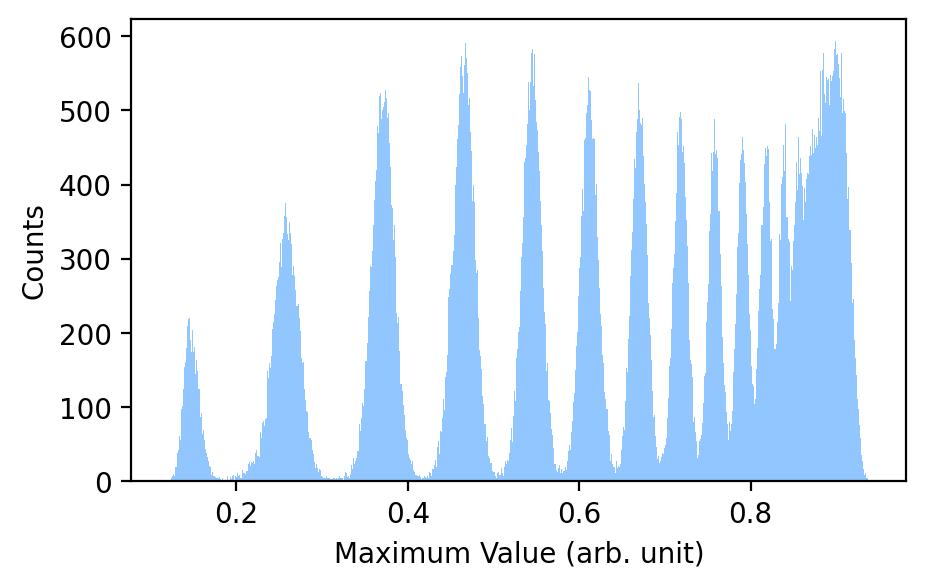

In [10]:
max_value = np.max(X_filter, axis=1)

plt.figure(figsize=(5,3), dpi=200)

pl = plt.hist(max_value, bins=700)

plt.xlabel("Maximum Value (arb. unit)")
plt.ylabel("Counts")
#plt.savefig('Presentation/MAX.png', transparent=True)

#### Clustering

Clusters:   0%|          | 0/29 [00:00<?, ?it/s]

Number of clusters :  12
Silhouette score :  0.694076581234815


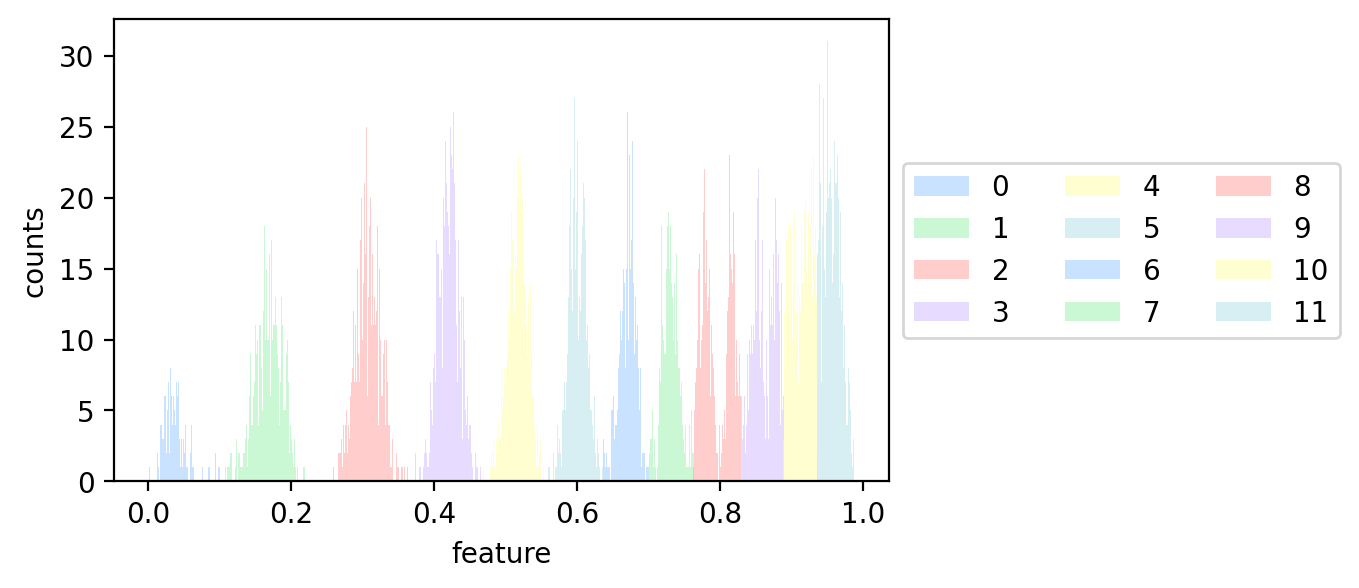

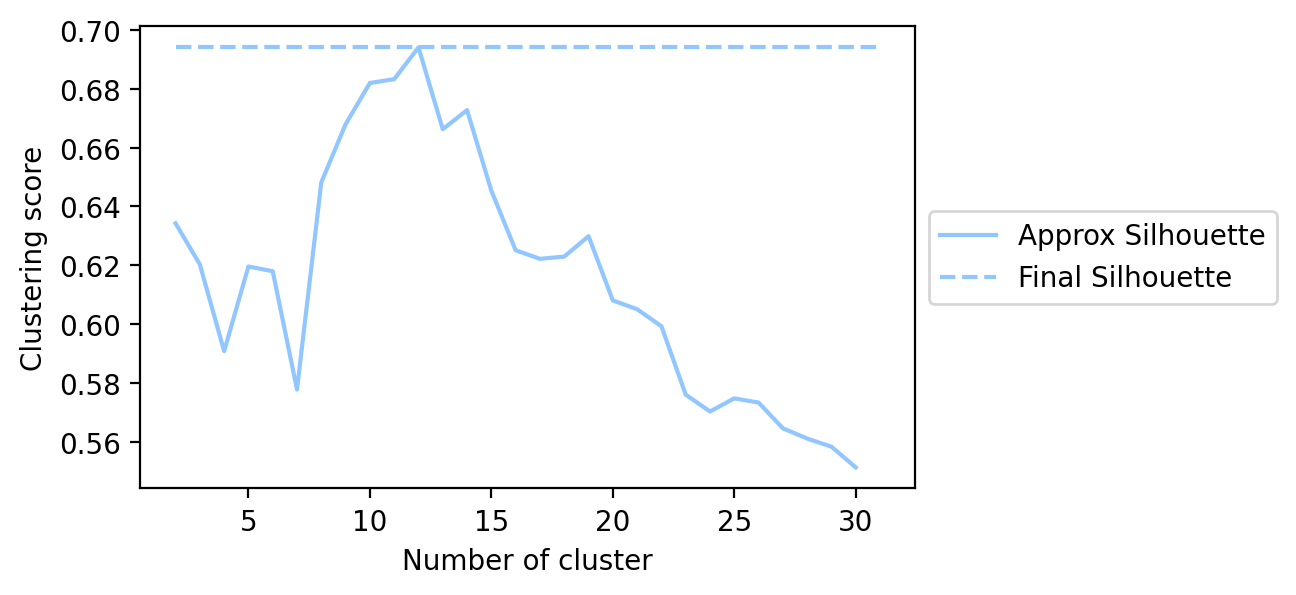

In [11]:
silhouette_kmean(max_value, 30)

### AREA

([], [])

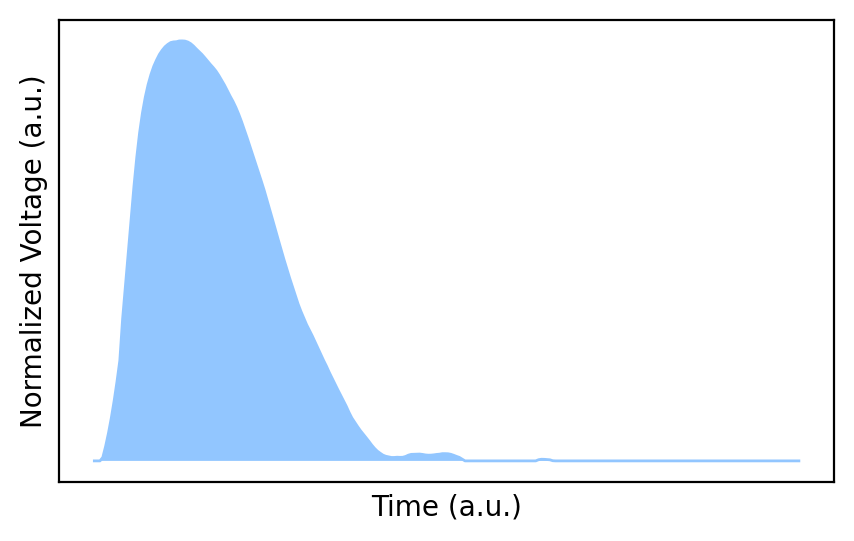

In [ ]:
X_area_temp = X_filter.copy()
X_area_temp[X_area_temp < 0.13] = 0.13

plt.figure(figsize=(5,3), dpi=200)

arg_max = np.argmax(X_area_temp[0])
plt.plot(time, X_area_temp[0], linewidth=1, alpha=1)
plt.fill_between(time, 0.13, X_area_temp[0])

plt.ylabel("Normalized Voltage (a.u.)")
plt.xlabel("Time (a.u.)")
plt.yticks([])
plt.xticks([])
#plt.savefig('Presentation/Trace_AREA.png', transparent=True)

Text(0, 0.5, 'Counts')

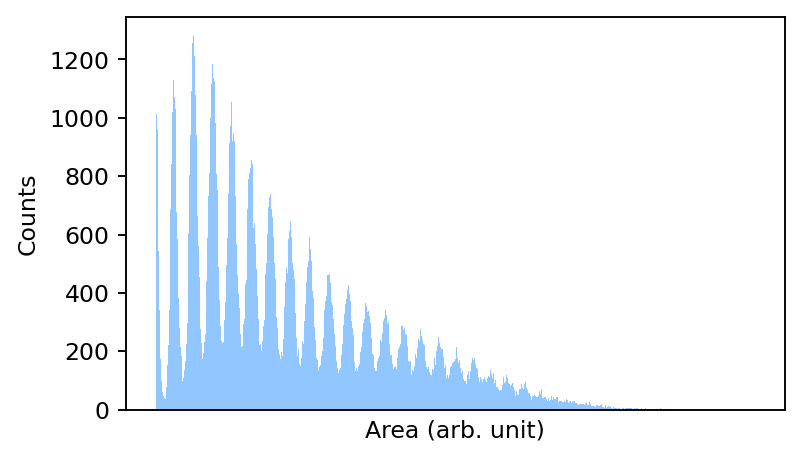

In [ ]:
X_area = trapz(X_area_temp, dx=1)

plt.figure(figsize=(5,3), dpi=170)
plt.hist(X_area, bins=700)

plt.xticks([])
plt.xlabel("Area (arb. unit)")
plt.ylabel("Counts")
#plt.savefig('Presentation/AREA.png', transparent=True)


#### Clustering

Clusters:   0%|          | 0/29 [00:00<?, ?it/s]

Number of clusters :  1
Silhouette score :  0


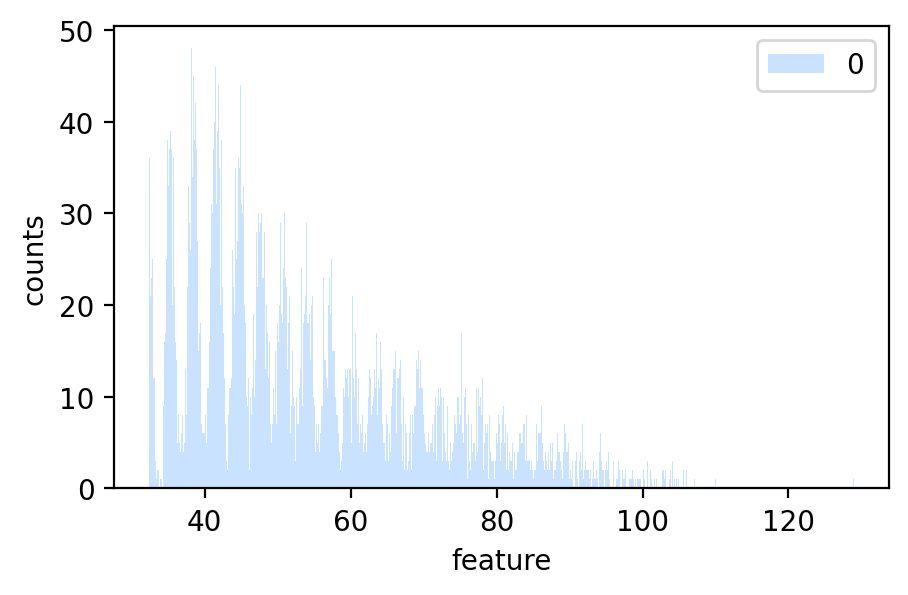

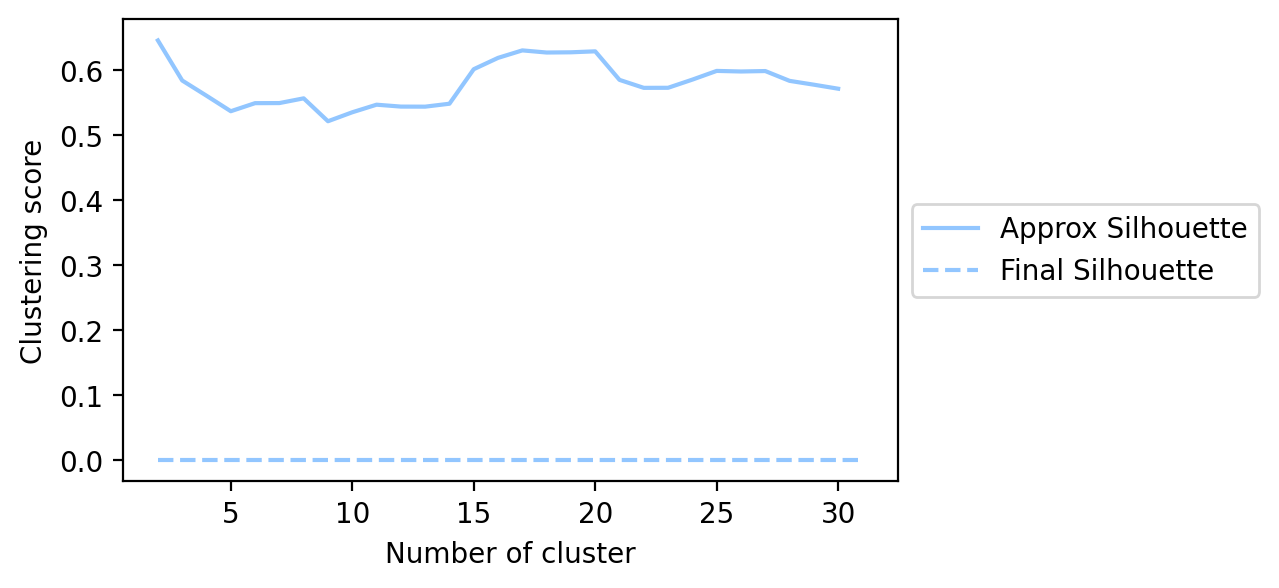

In [ ]:
silhouette_kmean(X_area, 30)

### PCA

Text(0, 0.5, 'Counts')

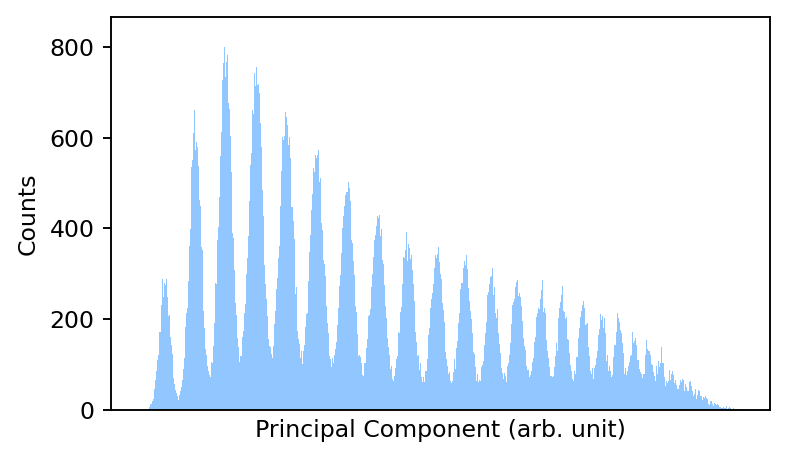

In [ ]:
pca = PCA(n_components=1, svd_solver="full")
X_pca = pca.fit_transform(X)

plt.figure(figsize=(5,3), dpi=170)

pl = plt.hist(X_pca, bins=700)

plt.xlabel("Principal Component (arb. unit)")
plt.ylabel("Counts")
#plt.savefig('Presentation/PCA.png', transparent=True)

([], [])

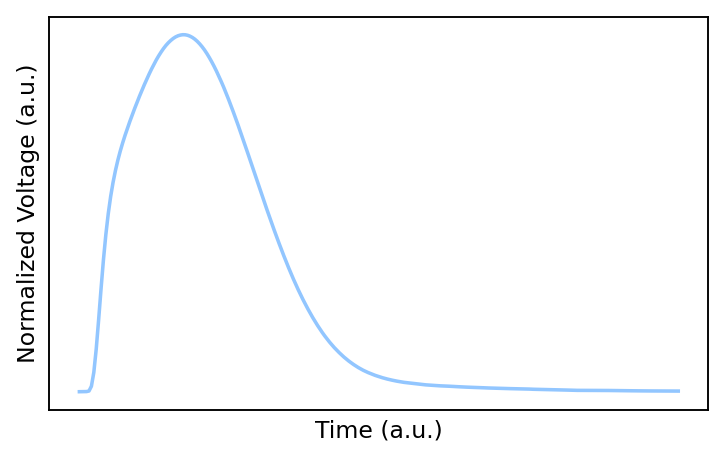

In [ ]:
N = 1
plt.figure(figsize=(5,3), dpi=170)

plot = [plt.plot(time, pca.components_[i], label=f"{i+1}") for i in range(N)]

plt.ylabel(r"Normalized Voltage (a.u.)")
plt.xlabel("Time (a.u.)")
plt.yticks([])
plt.xticks([])
#plt.savefig('Presentation/PCA_first.png', transparent=True)

Clusters:   0%|          | 0/29 [00:00<?, ?it/s]

Number of clusters :  18
Silhouette score :  0.6524906733973703


c:\Users\dalbe\anaconda3\envs\ML\lib\site-packages\IPython\core\events.py:89: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
c:\Users\dalbe\anaconda3\envs\ML\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


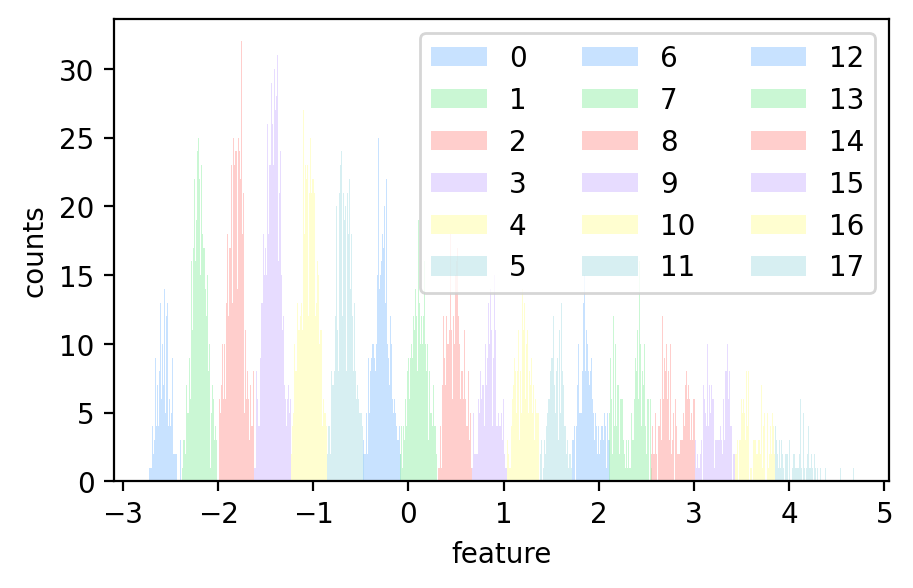

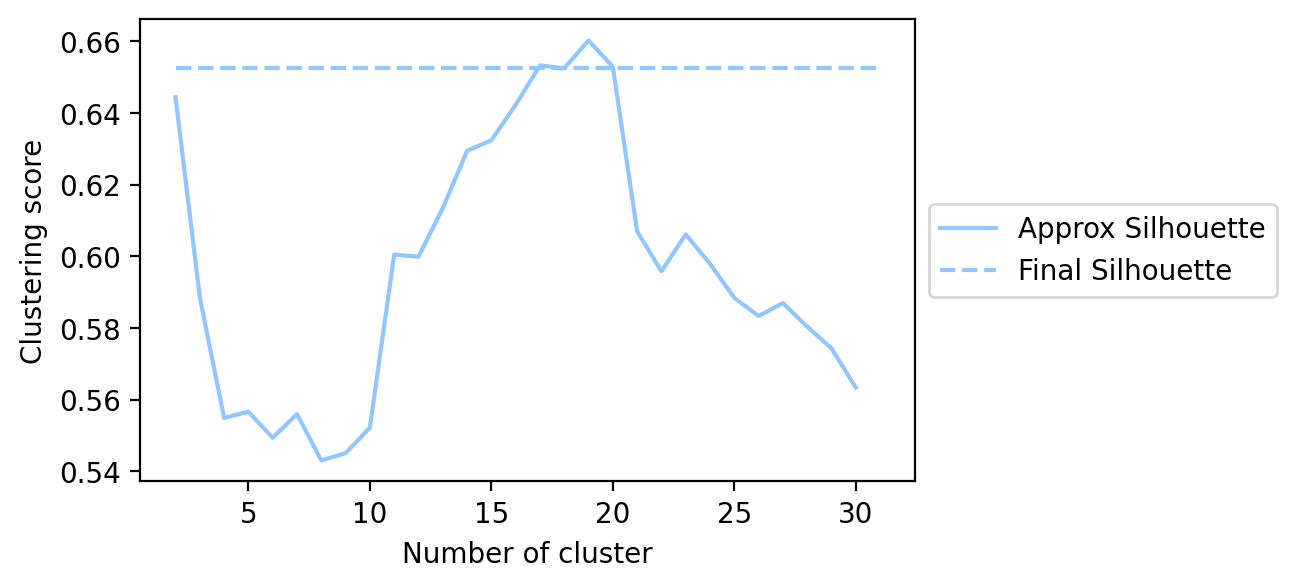

In [ ]:
silhouette_kmean(X_pca, 30)

### Autoencoder

In [ ]:
config = {
'files' : {
        'dataset'                  : "NIST (250)",
        'path_save'                : 'Autoencoder Log/',
        'input_dimension'          : 250
        },
'sweep' : {
        'sweep_name'               : None,
        'activation_possibilty'    : ['ReLU', 'Sigmoid', 'CELU', 'Softmax', 'Softmin', 'Hardshrink', 
                                        'LeakyReLU', 'ELU', 'LogSigmoid', 'PReLU', 'GELU', 'SiLU', 
                                        'Mish', 'Softplus', 'Softsign', 'Tanh'],
        'layer_size_possibility'   : [5,50,75,100,200],
        'search_type'              : 'grid_search',
        'search_param'             : [('train','epochs'),('train','learning_rate')]
        },
'run' : {
        'activation_list'          : ['GELU', 'PReLU', 'GELU'],
        'layer_list'               : [200, 50, 1, 50, 200],
        'layer_number'             : 4,
        },
'network' : {
        'output_dimension'         : 1,
        'skip_elements'            : 1,
        'layer_type'               : 'Linear',
        },
'train' : {
        'train_size'               : 0.8,
        'batch_number'             : 1,
        'k-fold'                   : 2, 
        'optimizer'                : 'adam',
        'criterion'                : 'MSELoss',
        'epochs'                   : 3,
        'learning_rate'            : 1e-4
        }
}

In [ ]:
from autoencoder import autoencoder, build_autoencoder

experiment = autoencoder()
model = build_autoencoder
network = model(config)

network.load_state_dict(torch.load(r"Autoencoder Log\run-2023-07-14-18-19\fold 2\model.pt"))
network.eval()

X_pytorch = torch.from_numpy(X_filter).view(-1, 1, int(signalSize)).float()

output = network(X_pytorch, encoding=True).detach().numpy().reshape(-1)
output = (output - np.min(output)) / (np.max(output) - np.min(output))

ModuleNotFoundError: No module named 'autoencoder'

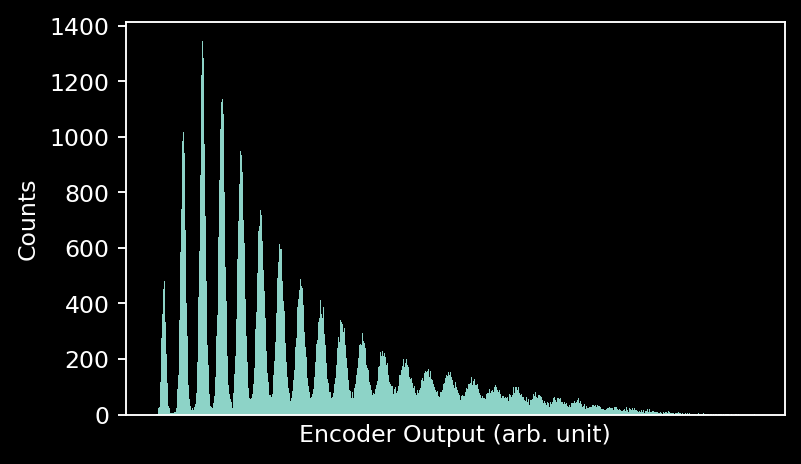

In [ ]:
plt.figure(figsize=(5,3), dpi=170)
pl = plt.hist(output, bins=1000)
plt.xticks([])
plt.xlabel("Encoder Output (arb. unit)")
plt.ylabel("Counts")
#plt.savefig('Presentation/encoder.png', transparent=True)
#plt.yscale("log")

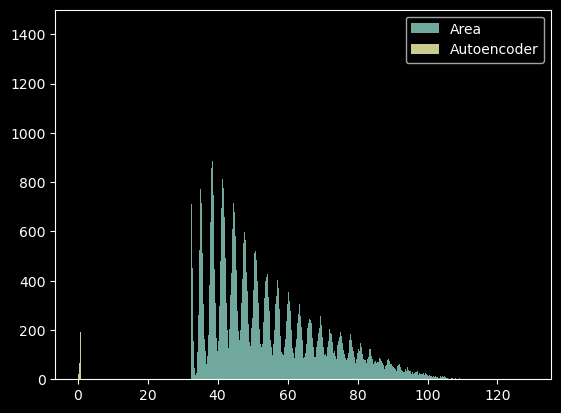

In [ ]:
plt.hist(area, bins=1000, alpha=0.8, label="Area")
plt.hist(output, bins=1000, alpha=0.8, label="Autoencoder")

#plt.yscale("log")
plt.ylim(0,1500)
plt.legend()

In [ ]:
def sigmoid(x):
    ''' It returns 1/(1+exp(-x)). where the values lies between zero and one '''

    return 1/(1+np.exp(-10*x))

In [ ]:
def RELU(x):
    ''' It returns zero if the input is less than zero otherwise it returns the given input. '''
    x1=[]
    for i in x:
        if i<0:
            x1.append(0)
        else:
            x1.append(i)

    return x1

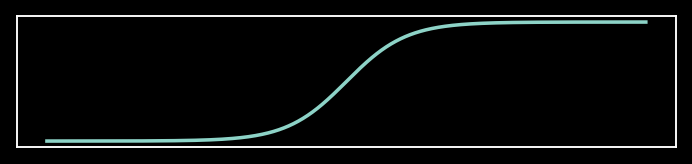

In [ ]:
x = np.linspace(-1,1,1000)

plt.figure(figsize=(5,1), dpi=170)
plt.xticks([])
plt.yticks([])
plt.plot(sigmoid(x))
#plt.savefig('Presentation/sigmoid.png', transparent=True)

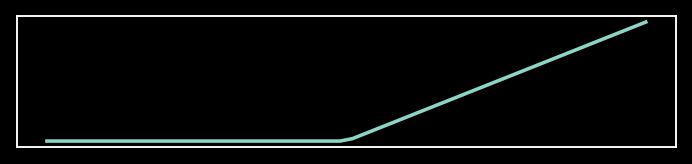

In [ ]:
x = np.linspace(-10, 10)

plt.figure(figsize=(5,1), dpi=170)
plt.plot(x, RELU(x))
plt.xticks([])
plt.yticks([])
#plt.savefig('Presentation/relu.png', transparent=True)